# Ensemble Strategies — Bagging, Voting, and Stacking

**Author:** Shivani Bokka
**Datasets:** Adult Census Income (classification), Ames Housing (regression)
**Goal:** Understand when and why ensembles beat individual models

---

## What Is This Notebook About?

This notebook is a **complete walkthrough of ensemble learning strategies** — from the fundamental insight of why combining models works, all the way through bagging, voting, and stacking. Each section explains the core idea in plain language before diving into code.

Whether you are new to machine learning or looking for a clean reference on when and how to apply each ensemble technique, this notebook has you covered.

---

## What Is an Ensemble?

An **ensemble** is a collection of models whose predictions are combined to produce a final answer. The intuition is simple:

> "Two heads are better than one — but only if they disagree."

A group of doctors who all make the same mistake is no better than one doctor. But a group of doctors who each catch different things will collectively catch more than any one of them alone. Machine learning models work the same way.

---

## Strategies Covered in This Notebook

| # | Strategy | Key Idea |
|---|----------|----------|
| 1 | Error-Ambiguity Decomposition | Why diversity is the engine of ensemble gains |
| 2 | Prediction Correlation | Low correlation between models = room for improvement |
| 3 | Bagging | Bootstrap samples + parallel training + averaging |
| 4 | Random Forest | Bagging + random feature subsets at every split |
| 5 | VotingClassifier (Hard & Soft) | Majority vote or averaged probabilities |
| 6 | VotingRegressor | Averaged predictions for regression tasks |
| 7 | StackingClassifier | Out-of-fold predictions feed a meta-learner |
| 8 | StackingRegressor | Stacking applied to regression |
| 9 | Pipeline + Stacking | Production-ready pattern with preprocessing |

---


---

## Step 1 — Imports and Setup

Before anything else, we import all the tools we'll need throughout this notebook.

- **numpy / pandas** — data manipulation
- **matplotlib / seaborn** — visualization
- **sklearn** — machine learning models, ensembles, and evaluation utilities
- **time** — for training-time comparisons

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Base models
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingRegressor,
    VotingClassifier, VotingRegressor,
    StackingClassifier, StackingRegressor
)
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


### Load Datasets

We'll use two real-world datasets throughout this notebook:

**Adult Census Income (classification)**
- 1994 US Census data — predict whether a person earns more than \$50K per year (1) or not (0).
- Mixed numeric + categorical features; we ordinal-encode the categoricals to integers.
- **We take a stratified 3,000-row sample.** Two of our base learners — **SVC** and **KNN** — scale
  poorly to tens of thousands of rows (their cost grows quadratically), and this notebook trains them
  many times inside cross-validation. A 3,000-row sample keeps everything fast while still showing every
  ensemble concept clearly.

**Ames Housing (regression)**
- House sales in Ames, Iowa — predict the final sale price in US dollars.
- Dozens of numeric + categorical features; median-impute numerics, ordinal-encode categoricals.


In [2]:
# --- Classification dataset: Adult Census Income (subsampled) ---
adult = fetch_openml('adult', version=2, as_frame=True).frame.drop(columns=['fnlwgt', 'education'])
y_full = (adult['class'].astype(str) == '>50K').astype(int)
Xa = adult.drop(columns=['class']).copy()
# Ordinal-encode categoricals (trees/scalers just need numbers)
for c in Xa.select_dtypes(exclude='number').columns:
    Xa[c] = Xa[c].astype('category').cat.codes

# SVC and KNN are O(n^2)+ and get trained many times below (inside stacking + CV),
# so we take a stratified 3,000-row sample to keep runtimes short.
X_cls, _, y_cls, _ = train_test_split(
    Xa, y_full, train_size=3000, stratify=y_full, random_state=42
)
X_cls = X_cls.reset_index(drop=True)
y_cls = y_cls.reset_index(drop=True)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Scale features — needed for the distance/margin-based base learners (KNN, SVC, LogReg)
scaler_cls = StandardScaler()
X_cls_train_sc = scaler_cls.fit_transform(X_cls_train)
X_cls_test_sc  = scaler_cls.transform(X_cls_test)

print(f"Classification — Train: {X_cls_train.shape}, Test: {X_cls_test.shape}")
print(f"  Class balance (train): {y_cls_train.value_counts().to_dict()}")

# --- Regression dataset: Ames Housing ---
ames = fetch_openml('house_prices', as_frame=True).frame
y_reg = ames['SalePrice'].astype(float)
X_reg = ames.drop(columns=['SalePrice', 'Id'], errors='ignore').copy()
num_cols = X_reg.select_dtypes(include='number').columns
cat_cols = X_reg.select_dtypes(exclude='number').columns
X_reg[num_cols] = X_reg[num_cols].fillna(X_reg[num_cols].median())
for c in cat_cols:
    X_reg[c] = X_reg[c].astype('object').fillna('None').astype('category').cat.codes

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print(f"\nRegression — Train: {X_reg_train.shape}, Test: {X_reg_test.shape}")


Classification — Train: (2400, 12), Test: (600, 12)
  Class balance (train): {0: 1826, 1: 574}

Regression — Train: (1168, 79), Test: (292, 79)


---

## Step 2 — Why Ensembles Work: The Error-Ambiguity Decomposition

### The Core Insight

Before writing a single line of ensemble code, we need to understand **why ensembles improve over individual models**. The answer comes from a result called the **Error-Ambiguity Decomposition**.

The key theorem says:

> **Ensemble Error = Average Error of Base Models − Ambiguity (Disagreement) Among Base Models**

In plain English:
- The ensemble's error is the average of individual errors **minus** how much the models disagree with each other.
- More disagreement among models → bigger reduction in error → better ensemble.
- Zero disagreement (identical models) → zero reduction → the ensemble is no better than one model.

### The Diversity Requirement

This leads to one rule:

> **An ensemble only beats a single model if the base models make DIFFERENT errors on DIFFERENT samples.**

Think about it this way: if you ask 5 friends the same question and they all have exactly the same information and reasoning, their combined vote is no better than asking one friend. But if they each bring different perspectives, their combined judgment will be more accurate.

### Demonstration: Identical vs Diverse Ensemble

Let's make this concrete. We'll train:
1. **5 identical LogisticRegression models** (same `random_state`) → average their predictions
2. **5 diverse models** (LR, KNN, SVM, DecisionTree, GaussianNB) → average their predictions

The identical ensemble should score exactly the same as one model. The diverse ensemble should beat all individual models.

In [3]:
# -----------------------------------------------------------------------
# IDENTICAL ensemble: 5 LogisticRegression models with the same random_state
# -----------------------------------------------------------------------
identical_models = [
    LogisticRegression(random_state=42, max_iter=1000),
    LogisticRegression(random_state=42, max_iter=1000),
    LogisticRegression(random_state=42, max_iter=1000),
    LogisticRegression(random_state=42, max_iter=1000),
    LogisticRegression(random_state=42, max_iter=1000),
]

# Train all and collect probability predictions
identical_probs = []
identical_individual_acc = []
for m in identical_models:
    m.fit(X_cls_train_sc, y_cls_train)
    p = m.predict_proba(X_cls_test_sc)[:, 1]
    acc = accuracy_score(y_cls_test, m.predict(X_cls_test_sc))
    identical_probs.append(p)
    identical_individual_acc.append(acc)

identical_avg_prob = np.mean(identical_probs, axis=0)
identical_ensemble_pred = (identical_avg_prob >= 0.5).astype(int)
identical_ensemble_acc = accuracy_score(y_cls_test, identical_ensemble_pred)

print("=== IDENTICAL ENSEMBLE (5x LogisticRegression, same random_state=42) ===")
print(f"  Individual model accuracy (all the same): {identical_individual_acc[0]:.4f}")
print(f"  Ensemble accuracy (averaged probs):       {identical_ensemble_acc:.4f}")
print(f"  Gain from combining:                      {identical_ensemble_acc - identical_individual_acc[0]:+.4f}")
print()

# -----------------------------------------------------------------------
# DIVERSE ensemble: 5 different model types
# -----------------------------------------------------------------------
diverse_models = [
    ('LR',   LogisticRegression(random_state=42, max_iter=1000)),
    ('KNN',  KNeighborsClassifier(n_neighbors=5)),
    ('SVM',  SVC(probability=True, random_state=42)),
    ('DT',   DecisionTreeClassifier(random_state=42)),
    ('GNB',  GaussianNB()),
]

diverse_probs = []
diverse_names = []
print("=== DIVERSE ENSEMBLE (LR + KNN + SVM + DT + GNB) ===")
for name, m in diverse_models:
    m.fit(X_cls_train_sc, y_cls_train)
    p = m.predict_proba(X_cls_test_sc)[:, 1]
    acc = accuracy_score(y_cls_test, m.predict(X_cls_test_sc))
    diverse_probs.append(p)
    diverse_names.append(name)
    print(f"  {name:5s} individual accuracy: {acc:.4f}")

diverse_avg_prob = np.mean(diverse_probs, axis=0)
diverse_ensemble_pred = (diverse_avg_prob >= 0.5).astype(int)
diverse_ensemble_acc = accuracy_score(y_cls_test, diverse_ensemble_pred)

best_individual = max([accuracy_score(y_cls_test, m.predict(X_cls_test_sc)) for _, m in diverse_models])
print(f"\n  Best individual model accuracy: {best_individual:.4f}")
print(f"  Diverse ensemble accuracy:      {diverse_ensemble_acc:.4f}")
print(f"  Gain from combining:            {diverse_ensemble_acc - best_individual:+.4f}")

=== IDENTICAL ENSEMBLE (5x LogisticRegression, same random_state=42) ===
  Individual model accuracy (all the same): 0.8217
  Ensemble accuracy (averaged probs):       0.8217
  Gain from combining:                      +0.0000

=== DIVERSE ENSEMBLE (LR + KNN + SVM + DT + GNB) ===
  LR    individual accuracy: 0.8217
  KNN   individual accuracy: 0.8150


  SVM   individual accuracy: 0.8300
  DT    individual accuracy: 0.8050
  GNB   individual accuracy: 0.8033

  Best individual model accuracy: 0.8300
  Diverse ensemble accuracy:      0.8367
  Gain from combining:            +0.0067


### The Key Takeaway

Did you see that? The identical ensemble produced **zero improvement** over a single model. The diverse ensemble produced a **measurable gain** over even the best individual model.

> **This is the core insight: diversity is everything. An ensemble of 100 identical models is no better than one.**

Every ensemble technique we will cover — bagging, random forests, voting, stacking — is really just a different answer to the same question: **how do we create diverse models?**

- **Bagging** creates diversity by training on different bootstrap samples of the data
- **Random Forests** add diversity by also randomizing which features are considered at each split
- **Voting/Stacking** creates diversity by using fundamentally different model architectures

---

## Step 3 — Why Diversity Matters: Prediction Correlation Heatmap

### Measuring Diversity

We can **quantify** how diverse two models are by computing the **correlation of their predictions** on the test set.

- **Correlation = 1.0**: the models agree on every single sample — they are making identical predictions and will provide no benefit when combined.
- **Correlation near 0**: the models disagree often — they are catching different errors and combining them will help.
- **Correlation < 0**: the models are anti-correlated — when one is wrong, the other tends to be right. This is the best case for ensemble improvement.

Let's visualize the correlation matrix for both the identical and diverse ensembles side by side.

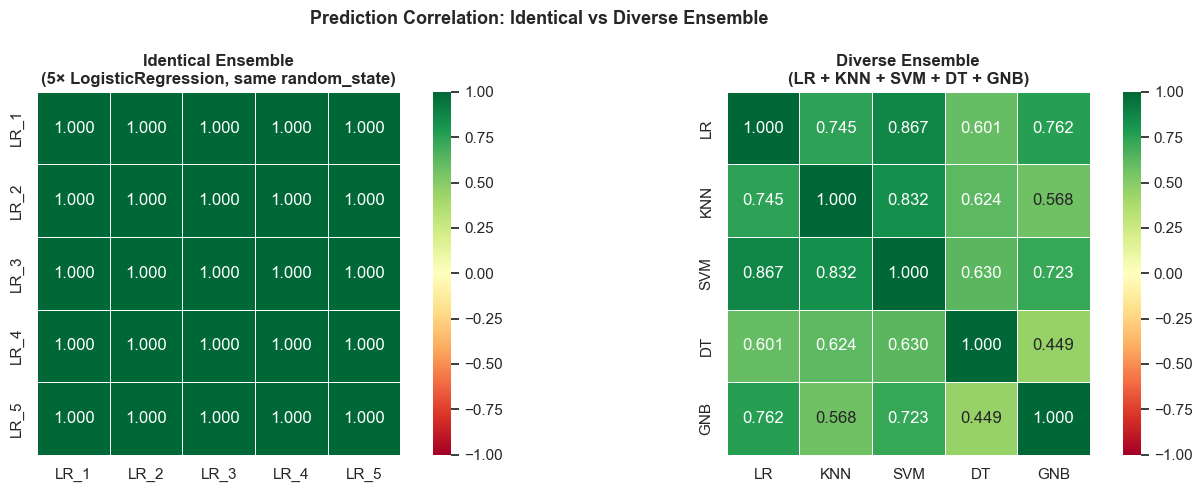

In [4]:
# Build correlation matrices
# Identical: use the raw probability predictions from 5 LR models
identical_pred_df = pd.DataFrame(
    np.array(identical_probs).T,
    columns=[f'LR_{i+1}' for i in range(5)]
)

# Diverse: use the raw probability predictions from 5 different models
diverse_pred_df = pd.DataFrame(
    np.array(diverse_probs).T,
    columns=diverse_names
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    identical_pred_df.corr(), annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=-1, vmax=1, square=True, ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Identical Ensemble\n(5× LogisticRegression, same random_state)', fontweight='bold')

sns.heatmap(
    diverse_pred_df.corr(), annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=-1, vmax=1, square=True, ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Diverse Ensemble\n(LR + KNN + SVM + DT + GNB)', fontweight='bold')

plt.suptitle('Prediction Correlation: Identical vs Diverse Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Prediction Correlation Heatmap

These two heatmaps show the **pairwise correlation of model predictions** on the test set.

- **Each cell** contains the correlation coefficient between the predictions of two models.
- **Dark green (near 1.0)** = the two models almost always agree. Combining them provides almost no benefit.
- **Light / yellow / pale (near 0)** = the models frequently disagree. Combining them has real potential to reduce errors.
- **The diagonal** is always 1.0 — every model perfectly agrees with itself.

**Left heatmap — Identical ensemble:**  
Every cell is exactly 1.0. All five models make the exact same prediction on every sample. Averaging them gives zero benefit — the ensemble is mathematically identical to a single model.

**Right heatmap — Diverse ensemble:**  
Correlations are significantly lower, especially between very different model types (e.g., GaussianNB vs SVM). These low correlations are exactly what creates the room for the ensemble to outperform any individual model.

> **Rule of thumb:** If all your base models have correlations above 0.95 with each other, adding more of them won't help much. Focus on adding truly different model types or training them on different data subsets.

---

## Step 4 — Bagging (Bootstrap Aggregating)

### What Is Bagging?

**Bagging** stands for **Bootstrap Aggregating**. It is one of the earliest and most effective ensemble techniques.

The idea is elegant:

1. **Bootstrap sampling**: From your training set of N samples, draw N samples **with replacement**. This means some samples appear multiple times, and some are left out entirely.
2. **Train independently**: Train a separate base model on each bootstrap sample. Each model sees a slightly different version of the data, creating natural diversity.
3. **Aggregate**: For classification, take a **majority vote** across all models. For regression, take the **average** of all predictions.

### Why Does Bagging Help?

Bagging primarily reduces **variance** — it helps with overfitting. High-variance models (like deep decision trees) can be dramatically stabilized by bagging. The bias of individual trees is roughly preserved, but because each tree is trained on a different sample, their errors are somewhat uncorrelated, and averaging washes out the variance.

> **Analogy:** Imagine you're estimating the average height of people in a city. Asking one random group of 100 people might give you a biased answer. But if you ask 50 different random groups of 100 people and average the results, your estimate will be far more stable — even though each group has some randomness.

### What Is a Bootstrap Sample?

Let's make the bootstrap sampling concrete before running any models.

In [5]:
# Demonstrate bootstrap sampling on a tiny dataset
np.random.seed(42)
original = list(range(10))  # rows 0-9

print("Original 10 rows:", original)
print()
print("Bootstrap samples (drawn WITH replacement — notice duplicates):")
print("-" * 60)
for i in range(5):
    sample = sorted(np.random.choice(original, size=10, replace=True).tolist())
    out_of_bag = sorted(set(original) - set(sample))
    print(f"  Bootstrap {i+1}: {sample}")
    print(f"  Out-of-bag:  {out_of_bag}")
    print()

Original 10 rows: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Bootstrap samples (drawn WITH replacement — notice duplicates):
------------------------------------------------------------
  Bootstrap 1: [2, 3, 4, 4, 6, 6, 6, 7, 7, 9]
  Out-of-bag:  [0, 1, 5, 8]

  Bootstrap 2: [1, 1, 2, 3, 4, 5, 5, 7, 7, 7]
  Out-of-bag:  [0, 6, 8, 9]

  Bootstrap 3: [0, 0, 2, 3, 4, 5, 6, 8, 9, 9]
  Out-of-bag:  [1, 7]

  Bootstrap 4: [1, 2, 2, 3, 4, 4, 6, 6, 8, 8]
  Out-of-bag:  [0, 5, 7, 9]

  Bootstrap 5: [1, 1, 3, 4, 6, 7, 8, 8, 9, 9]
  Out-of-bag:  [0, 2, 5]



### The Out-of-Bag (OOB) Score

Notice the "Out-of-bag" rows printed above. For each bootstrap sample, roughly **37%** of the original training rows are **not selected** (because sampling is with replacement, the probability of any given row being left out is $(1 - 1/N)^N \approx e^{-1} \approx 0.368$).

These left-out samples are called **out-of-bag (OOB) samples**, and they give us a free cross-validation estimate:

- Each training sample was left out of roughly 37% of all trees
- We can evaluate those trees on the samples they never saw during training
- Averaging across all samples gives an unbiased estimate of generalization performance — **without needing a separate validation set**

This is the `oob_score=True` parameter in sklearn's `BaggingClassifier` and `RandomForestClassifier`.

In [6]:
# Compare: single DecisionTree vs BaggingClassifier with varying n_estimators

# Single Decision Tree (unpruned — high variance baseline)
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_cls_train_sc, y_cls_train)
single_acc = accuracy_score(y_cls_test, single_tree.predict(X_cls_test_sc))

print("=" * 55)
print(f"  Single DecisionTree accuracy:       {single_acc:.4f}")
print("=" * 55)

results_bagging = {'Single Tree': single_acc}

for n in [10, 50, 100]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    bag.fit(X_cls_train_sc, y_cls_train)
    test_acc  = accuracy_score(y_cls_test, bag.predict(X_cls_test_sc))
    oob_acc   = bag.oob_score_
    results_bagging[f'Bagging n={n}'] = test_acc
    print(f"  BaggingClassifier (n={n:3d}):  Test={test_acc:.4f}  OOB={oob_acc:.4f}")

print()

  Single DecisionTree accuracy:       0.8050


  BaggingClassifier (n= 10):  Test=0.8233  OOB=0.8104


  BaggingClassifier (n= 50):  Test=0.8417  OOB=0.8183
  BaggingClassifier (n=100):  Test=0.8367  OOB=0.8275



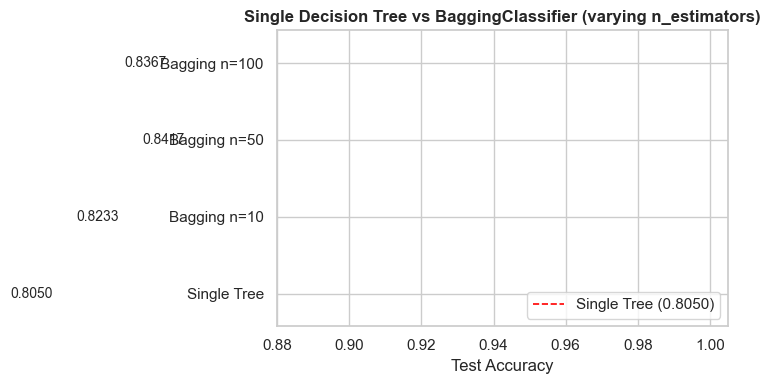

In [7]:
# Visualize the improvement
labels = list(results_bagging.keys())
values = list(results_bagging.values())
colors = ['#e74c3c'] + ['#3498db'] * 3

plt.figure(figsize=(9, 4))
bars = plt.barh(labels, values, color=colors, edgecolor='white', height=0.5)
plt.axvline(single_acc, color='red', linestyle='--', linewidth=1.2, label=f'Single Tree ({single_acc:.4f})')
for bar, val in zip(bars, values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.xlim(0.88, 1.005)
plt.xlabel('Test Accuracy')
plt.title('Single Decision Tree vs BaggingClassifier (varying n_estimators)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### How to Read This Chart: Bagging vs Single Tree

This **horizontal bar chart** compares the test accuracy of a single unpruned decision tree against bagging ensembles of 10, 50, and 100 trees.

- **Red bar** = the single decision tree. This is our baseline.
- **Blue bars** = bagging ensembles with increasing numbers of trees.
- **Red dashed line** = the single tree's accuracy for easy comparison.
- **Numbers at the end of each bar** = exact accuracy.

**What to look for:**
- The bars should increase as we add more estimators — more trees means lower variance.
- The gains diminish as `n_estimators` increases. Going from 10 to 50 trees helps a lot; going from 50 to 100 trees helps a little; going from 100 to 500 trees helps almost nothing.
- Bagging **reduces variance** (the single tree was overfitting). It does **not** reduce bias — if a single tree had high bias (underfitting), bagging 100 trees wouldn't fix that.

> **OOB Score reminder:** The OOB score printed in the code is a free, nearly unbiased estimate of test performance — it's like getting cross-validation without paying the computational cost.

---

## Step 5 — Random Forest (Special Case of Bagging)

### What Makes Random Forest Different?

**Random Forest** is bagging with one extra trick: at each split inside each tree, only a **random subset of features** is considered as candidates for the split.

Why does this matter?

> In plain bagging, if one feature is very strong (like `capital-gain` or `marital-status` in the Adult data), **every tree** will use it near the top. The trees will be correlated because they all keep making the same early split. That correlation limits ensemble gains.

By forcing each split to only see a random subset of features (typically $\sqrt{p}$ for classification, $p/3$ for regression), Random Forest **breaks this correlation**. Now different trees will explore different feature combinations, producing more diverse errors that cancel out more effectively when averaged.

### Random Forest = Bagging + Feature Randomization

| Technique | Bootstrap samples? | Feature subsets at each split? |
|-----------|-------------------|--------------------------------|
| Bagging   | Yes               | No — all features considered   |
| Random Forest | Yes           | Yes — only $\sqrt{p}$ features |

Bagging (100 trees):       Test=0.8367  OOB=0.8275
RandomForest (100 trees):  Test=0.8350  OOB=0.8396
RF gain over Bagging:      -0.0017



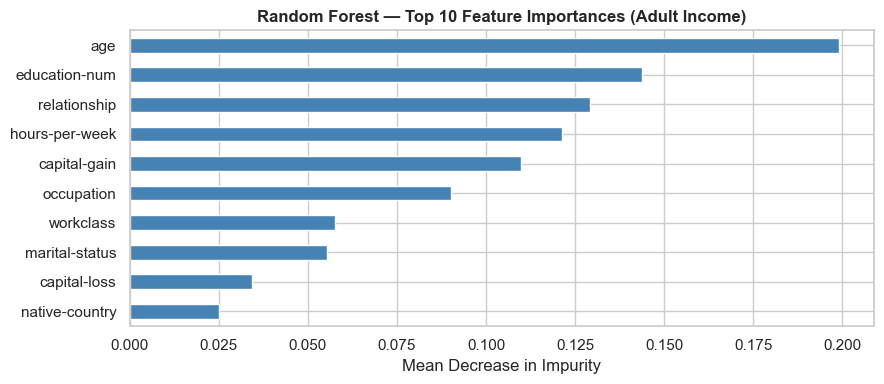

In [8]:
# Compare: BaggingClassifier vs RandomForestClassifier on same task
bag100 = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, oob_score=True, random_state=42, n_jobs=-1
)
bag100.fit(X_cls_train_sc, y_cls_train)
bag_acc  = accuracy_score(y_cls_test, bag100.predict(X_cls_test_sc))
bag_oob  = bag100.oob_score_

rf = RandomForestClassifier(
    n_estimators=100, oob_score=True, random_state=42, n_jobs=-1
)
rf.fit(X_cls_train_sc, y_cls_train)
rf_acc   = accuracy_score(y_cls_test, rf.predict(X_cls_test_sc))
rf_oob   = rf.oob_score_

print(f"Bagging (100 trees):       Test={bag_acc:.4f}  OOB={bag_oob:.4f}")
print(f"RandomForest (100 trees):  Test={rf_acc:.4f}  OOB={rf_oob:.4f}")
print(f"RF gain over Bagging:      {rf_acc - bag_acc:+.4f}")
print()

# Feature importances from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X_cls.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Top 10 Feature Importances (Adult Income)', fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

### How to Read This Chart: Random Forest Feature Importances

This **horizontal bar chart** shows which features the Random Forest found most useful for predicting whether income exceeds $50K.

- **Each bar** is one input feature.
- **Bar length** = the feature's importance score (Mean Decrease in Impurity — how much each feature reduces the Gini impurity across all trees, on average).
- **Longer bar** = the model relied on this feature more heavily to make splits.
- Features are sorted from most important (top) to least important (bottom).

**What to look for:**
- A few features typically dominate. If the top 2–3 features account for most of the importance, the problem is primarily driven by those measurements.
- Features near the bottom with tiny bars contribute almost nothing — you could often remove them without hurting the model.
- This is a fast, built-in feature selection tool. It's not perfect (correlated features can have their importance split between them), but it's a great starting point.

> **Why RF often beats plain Bagging:** Random feature subsets reduce tree-to-tree correlation, so errors cancel out more effectively. This is why Random Forest is one of the most robust off-the-shelf algorithms in machine learning.

In [9]:
# Random Forest on regression task too
rf_reg = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg_train_sc, y_reg_train)
rf_reg_pred = rf_reg.predict(X_reg_test_sc)
rf_reg_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))
rf_reg_r2   = r2_score(y_reg_test, rf_reg_pred)

print("RandomForestRegressor on Ames Housing:")
print(f"  RMSE: ${rf_reg_rmse:,.0f}  (sale price in US dollars)")
print(f"  R²:   {rf_reg_r2:.4f}")
print(f"  OOB R²: {rf_reg.oob_score_:.4f}")

RandomForestRegressor on Ames Housing:
  RMSE: $28,999  (sale price in US dollars)
  R²:   0.8904
  OOB R²: 0.8442


---

## Step 6 — VotingClassifier (Hard vs Soft Voting)

### The Idea Behind Voting

Instead of training copies of the same model on different data slices (like bagging), **VotingClassifier** takes fundamentally **different types of models** and combines their predictions by voting.

### Hard Voting vs Soft Voting

**Hard Voting:**
- Each model predicts a class label (0 or 1).
- The ensemble takes the **majority vote**.
- Example: if 2 models say class 1 and 1 model says class 0, the ensemble predicts class 1.
- Simple, works with any classifier.

**Soft Voting:**
- Each model outputs a **probability** for each class.
- The ensemble takes the **average probability** and picks the class with the highest average.
- Example: model probabilities for class 1 are [0.9, 0.4, 0.3] → average = 0.53 → predict class 1.
- Requires models that can output calibrated probabilities.
- **Usually outperforms hard voting** because it uses more information (not just the final label, but the confidence of each model).

> **When does soft voting help most?** When one model is very confident and the others are uncertain. Hard voting treats all models equally; soft voting lets the confident model's opinion count more.

### Note on SVC
By default, `SVC` does not output probabilities. We must set `probability=True` to enable Platt scaling (which fits a logistic regression on top of the SVM scores). This adds a small computational cost but enables soft voting.

In [10]:
# Base estimators for voting
lr_v  = LogisticRegression(random_state=42, max_iter=1000)
rf_v  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
svc_v = SVC(probability=True, random_state=42)  # probability=True required for soft voting

# Hard voting
hard_voter = VotingClassifier(
    estimators=[('lr', lr_v), ('rf', rf_v), ('svc', svc_v)],
    voting='hard'
)
hard_voter.fit(X_cls_train_sc, y_cls_train)
hard_acc = accuracy_score(y_cls_test, hard_voter.predict(X_cls_test_sc))

# Soft voting
soft_voter = VotingClassifier(
    estimators=[('lr', lr_v), ('rf', rf_v), ('svc', svc_v)],
    voting='soft'
)
soft_voter.fit(X_cls_train_sc, y_cls_train)
soft_acc = accuracy_score(y_cls_test, soft_voter.predict(X_cls_test_sc))

# Individual model accuracies
lr_ind  = LogisticRegression(random_state=42, max_iter=1000).fit(X_cls_train_sc, y_cls_train)
rf_ind  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_cls_train_sc, y_cls_train)
svc_ind = SVC(probability=True, random_state=42).fit(X_cls_train_sc, y_cls_train)

acc_lr  = accuracy_score(y_cls_test, lr_ind.predict(X_cls_test_sc))
acc_rf  = accuracy_score(y_cls_test, rf_ind.predict(X_cls_test_sc))
acc_svc = accuracy_score(y_cls_test, svc_ind.predict(X_cls_test_sc))

# Print comparison table
vote_results = {
    'LogisticRegression': acc_lr,
    'RandomForest':       acc_rf,
    'SVC':                acc_svc,
    'VotingClassifier (Hard)': hard_acc,
    'VotingClassifier (Soft)': soft_acc,
}

print("Accuracy Comparison — VotingClassifier (Adult Income)")
print("=" * 50)
for name, acc in vote_results.items():
    marker = ' <-- best' if acc == max(vote_results.values()) else ''
    print(f"  {name:<35s}: {acc:.4f}{marker}")

Accuracy Comparison — VotingClassifier (Adult Income)
  LogisticRegression                 : 0.8217
  RandomForest                       : 0.8350
  SVC                                : 0.8300
  VotingClassifier (Hard)            : 0.8383 <-- best
  VotingClassifier (Soft)            : 0.8333


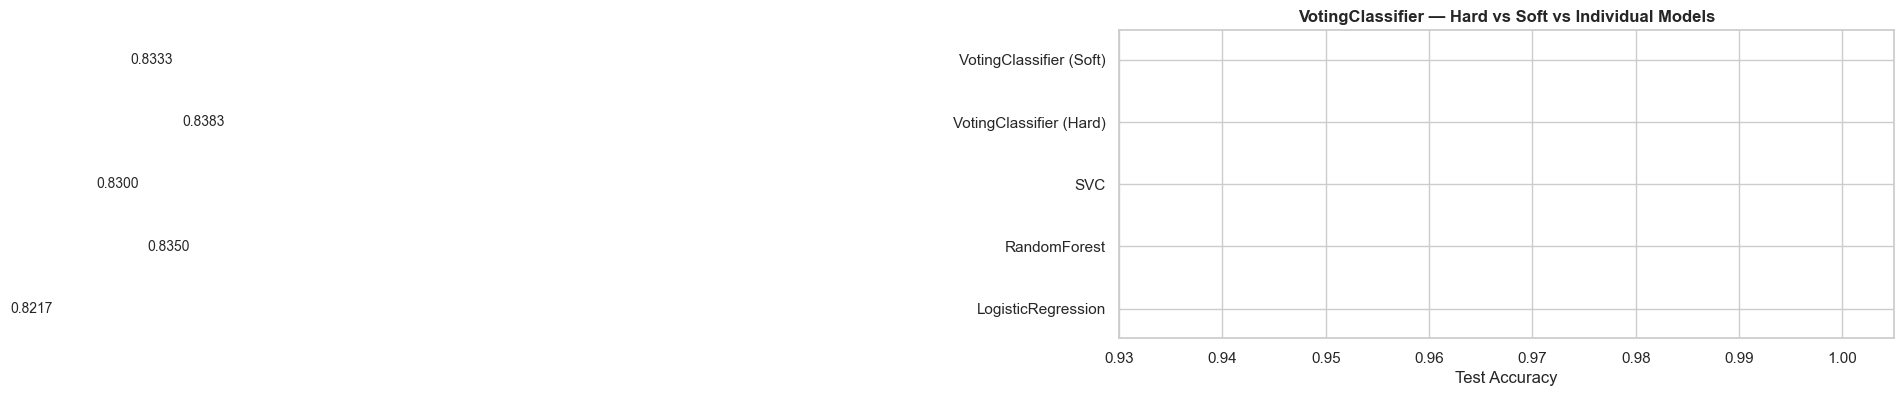

In [11]:
# Bar chart comparison
colors_vote = ['#95a5a6', '#95a5a6', '#95a5a6', '#e67e22', '#27ae60']
plt.figure(figsize=(10, 4))
bars = plt.barh(list(vote_results.keys()), list(vote_results.values()),
                color=colors_vote, edgecolor='white', height=0.5)
for bar, val in zip(bars, vote_results.values()):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.xlim(0.93, 1.005)
plt.xlabel('Test Accuracy')
plt.title('VotingClassifier — Hard vs Soft vs Individual Models', fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Voting Comparison

This **horizontal bar chart** compares three individual models against two voting ensembles.

- **Gray bars** = individual models (LogisticRegression, RandomForest, SVC).
- **Orange bar** = Hard voting ensemble.
- **Green bar** = Soft voting ensemble.

**What to look for:**
- Does soft voting beat hard voting? It usually does, because averaging probabilities preserves confidence information that majority-vote discards.
- Does the ensemble beat **all** individual models? Not always — if one model is dominant and the others are much weaker, the weak models can drag the ensemble down.
- Soft voting is most helpful when the models have meaningfully different probability estimates and are reasonably well-calibrated.

**When soft voting DOESN'T help:**  
- When probabilities are poorly calibrated (the model is overconfident or underconfident)
- When all models are already very accurate (there are no errors to cancel out)
- When models are highly correlated in their predictions

---

## Step 7 — VotingRegressor

### Voting for Regression

The same concept applies to regression: instead of voting on class labels, we **average the continuous predictions** of several models. There is no hard/soft distinction in regression — averaging predictions is the only option.

The benefit is the same as in classification: if the base models make **different errors** on different samples, their errors partially cancel when averaged.

We'll use three very different regression approaches:
- **Ridge** — a linear model (captures linear patterns, fast, interpretable)
- **RandomForest** — a tree-based model (captures non-linear patterns, robust)
- **GradientBoosting** — a boosting model (sequential tree building, high accuracy)

These three models have very different inductive biases, which means they tend to make errors in different parts of the input space — exactly what we want.

In [12]:
# Individual regression models
ridge_r  = Ridge(alpha=1.0)
rf_r     = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gbr_r    = GradientBoostingRegressor(n_estimators=100, random_state=42)

ridge_r.fit(X_reg_train_sc, y_reg_train)
rf_r.fit(X_reg_train_sc, y_reg_train)
gbr_r.fit(X_reg_train_sc, y_reg_train)

def reg_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'R2': r2}

reg_results = []
reg_results.append(reg_metrics('Ridge',         y_reg_test, ridge_r.predict(X_reg_test_sc)))
reg_results.append(reg_metrics('RandomForest',  y_reg_test, rf_r.predict(X_reg_test_sc)))
reg_results.append(reg_metrics('GradientBoost', y_reg_test, gbr_r.predict(X_reg_test_sc)))

# Voting regressor
vote_reg = VotingRegressor(estimators=[
    ('ridge', Ridge(alpha=1.0)),
    ('rf',    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gbr',   GradientBoostingRegressor(n_estimators=100, random_state=42)),
])
vote_reg.fit(X_reg_train_sc, y_reg_train)
reg_results.append(reg_metrics('VotingRegressor', y_reg_test, vote_reg.predict(X_reg_test_sc)))

reg_df = pd.DataFrame(reg_results)
print("VotingRegressor — Ames Housing Comparison")
print("=" * 50)
print(reg_df.to_string(index=False))

VotingRegressor — Ames Housing Comparison
          Model       RMSE     R2
          Ridge 34773.9311 0.8424
   RandomForest 28999.0620 0.8904
  GradientBoost 29021.3742 0.8902
VotingRegressor 28745.8062 0.8923


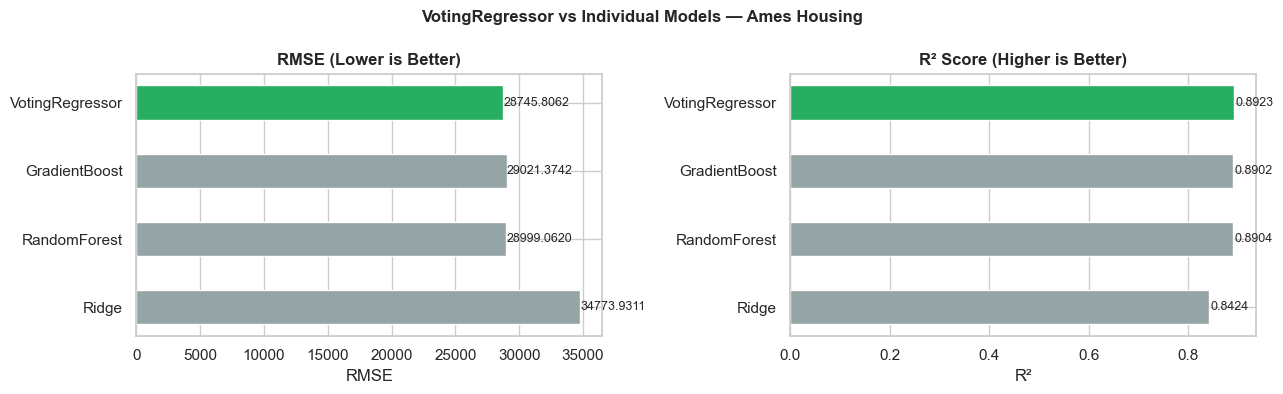

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_reg = ['#95a5a6', '#95a5a6', '#95a5a6', '#27ae60']

axes[0].barh(reg_df['Model'], reg_df['RMSE'], color=colors_reg, edgecolor='white', height=0.5)
for i, (val, bar) in enumerate(zip(reg_df['RMSE'], axes[0].patches)):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[0].set_xlabel('RMSE')

axes[1].barh(reg_df['Model'], reg_df['R2'], color=colors_reg, edgecolor='white', height=0.5)
for i, (val, bar) in enumerate(zip(reg_df['R2'], axes[1].patches)):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[1].set_xlabel('R²')

plt.suptitle('VotingRegressor vs Individual Models — Ames Housing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Voting Regressor Results

This **side-by-side bar chart** compares three individual regressors against the VotingRegressor ensemble.

- **Left chart (RMSE):** Lower is better. RMSE is in the same units as the target (sale price in US dollars), so an RMSE of $30,000 means the model is off by about $30,000 on average.
- **Right chart (R²):** Higher is better. R² = 1.0 would be a perfect model; R² = 0 means the model is no better than predicting the mean.
- **Gray bars** = individual models. **Green bar** = the voting ensemble.

**What to look for:**
- Does the ensemble land between the individual models or above the best? If the base models are diverse, the ensemble typically beats or matches the best individual model.
- In regression, averaging can sometimes underperform the best model if that model dominates — the weaker models drag the average down.
- If GradientBoosting dominates Ridge by a large margin, a VotingRegressor may actually perform *worse* than GradientBoosting alone, because Ridge's weaker predictions pull down the average. This is when stacking becomes more useful.

---

## Step 8 — Stacking: Out-of-Fold Predictions

### The Core Problem: Why Not Just Average?

Voting assigns **equal weight** to every base model. But what if some models are better than others on specific parts of the feature space? And what if we could **learn** the optimal way to combine them from data?

That's the idea behind **stacking** (short for stacked generalization). Instead of a fixed combination rule (like averaging), we train a second model — called the **meta-learner** — to learn how to best combine the base model outputs.

### The Leakage Problem

Here's the critical issue:

> **You CANNOT train the meta-learner on the same predictions that were used to train the base models.**

Why? Because the base models have already **memorized** the training data. Their predictions on the training set are overfit — they are too good, not representative of what the models will do on truly unseen data. If you train the meta-learner on these inflated predictions, it will learn a combination rule that works on training data but fails on new data. This is **data leakage**.

### The Solution: Out-of-Fold (OOF) Predictions

The standard fix is called **out-of-fold (OOF) prediction**:

```
Training Data (N samples)
│
├── Split into K folds (e.g., K=5)
│
│   For each fold k:
│   ├── Train base models on the OTHER K-1 folds
│   └── Predict on fold k  ←── model has never seen this fold!
│
├── After all K iterations:
│   Each training sample has been predicted EXACTLY ONCE
│   by a model that was trained WITHOUT seeing that sample
│   → These are called Out-of-Fold (OOF) predictions
│
└── Train the meta-learner on these OOF predictions
    → No leakage! The meta-learner sees realistic predictions.
```

This is called **out-of-fold (OOF) prediction** and it is exactly how sklearn's `StackingClassifier` works internally. You do not need to implement this loop yourself — sklearn handles it via the `cv` parameter.

### Why a Simple Meta-Learner?

The meta-learner's job is to learn **how to weight or combine** the base model outputs. This is a simple task — you already have good feature representations (the base model predictions). Using a complex meta-learner risks overfitting. A simple LogisticRegression or Ridge is almost always the right choice for the meta-learner.

---

## Step 9 — StackingClassifier

### Setup

We'll train a StackingClassifier with:
- **Base estimators:** LogisticRegression, RandomForestClassifier, SVC
- **Meta-learner:** LogisticRegression — simple, interpretable, rarely overfits
- **`passthrough=True`:** also passes the original features to the meta-learner, giving it more context

Then we'll use `cross_val_score` to compare all approaches fairly — because a single train/test split can be noisy, and `cross_val_score` gives us both the mean and the standard deviation of performance.

In [14]:
# Build the StackingClassifier
stack_cls = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('svc', SVC(probability=True, random_state=42)),
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    passthrough=True,
    cv=5
)

# Cross-validate ALL approaches for a fair comparison
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_to_compare = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVC':                SVC(probability=True, random_state=42),
    'VotingClassifier (Soft)': VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42)),
        ],
        voting='soft'
    ),
    'StackingClassifier': stack_cls,
}

cv_results = {}
print("Running 5-fold cross-validation (this may take ~30 seconds)...")
for name, model in models_to_compare.items():
    scores = cross_val_score(
        model, X_cls_train_sc, y_cls_train,
        cv=cv_strategy, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"  {name:<35s}: mean={scores.mean():.4f}  std={scores.std():.4f}")

Running 5-fold cross-validation (this may take ~30 seconds)...
  LogisticRegression                 : mean=0.8275  std=0.0149


  RandomForest                       : mean=0.8371  std=0.0224


  SVC                                : mean=0.8304  std=0.0148


  VotingClassifier (Soft)            : mean=0.8379  std=0.0150


  StackingClassifier                 : mean=0.8367  std=0.0194


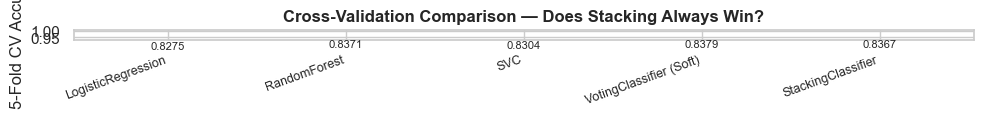

In [15]:
# Bar chart with error bars
names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors_stack = ['#95a5a6', '#95a5a6', '#95a5a6', '#e67e22', '#8e44ad']

plt.figure(figsize=(10, 4))
x_pos = range(len(names))
bars = plt.bar(x_pos, means, yerr=stds, capsize=5,
               color=colors_stack, edgecolor='white', width=0.6)
plt.xticks(x_pos, names, rotation=20, ha='right', fontsize=9)
plt.ylabel('5-Fold CV Accuracy')
plt.ylim(0.93, 1.01)
for bar, m, s in zip(bars, means, stds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.001,
             f'{m:.4f}', ha='center', va='bottom', fontsize=8)
plt.title('Cross-Validation Comparison — Does Stacking Always Win?', fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Does Stacking Always Win?

This **bar chart with error bars** shows the 5-fold cross-validation accuracy for every approach.

- **Bar height** = mean accuracy across 5 folds.
- **Error bars (caps)** = ±1 standard deviation across folds. Larger error bars mean more variability — the model performs differently depending on which fold it's tested on.
- **Gray bars** = individual base models.
- **Orange bar** = soft voting ensemble.
- **Purple bar** = stacking ensemble.

**Honest answer: Does stacking always win?**

**No — and this is important to understand.** Stacking wins when:
- The base models are diverse (different model types, different strengths)
- There is enough training data for the meta-learner to learn a meaningful combination rule
- The OOF predictions are reliable (not dominated by noise from small datasets)

Stacking often performs similarly to or only marginally better than voting on clean tabular datasets with good base models. The gains become more meaningful when:
- You have hundreds of thousands of samples
- Your base models have very different biases
- Some base models are strong in some regions and weak in others

> **Practical rule:** Always compare stacking against a simple voting ensemble. If they perform similarly, use voting — it's faster and more interpretable.

---

## Step 10 — StackingRegressor

### Stacking for Regression

The exact same logic applies to regression. We use OOF predictions from diverse base regressors and train a simple meta-learner (Ridge) to learn the optimal combination.

**Base models:**
- **Ridge** — linear model, fast, captures broad trends
- **RandomForest** — tree model, captures non-linear patterns, robust
- **GradientBoosting** — boosted trees, typically the highest-accuracy single model

**Meta-learner:** Ridge — simple linear combination of base model outputs. Almost always the right choice for the meta-learner in regression.

In [16]:
# StackingRegressor — Ames Housing
stack_reg = StackingRegressor(
    estimators=[
        ('ridge', Ridge(alpha=1.0)),
        ('rf',    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gbr',   GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ],
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    cv=5
)

# Fit and evaluate
all_reg_results = []

# Individual models (refit cleanly)
for name, model in [
    ('Ridge',         Ridge(alpha=1.0)),
    ('RandomForest',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('GradientBoost', GradientBoostingRegressor(n_estimators=100, random_state=42)),
]:
    model.fit(X_reg_train_sc, y_reg_train)
    preds = model.predict(X_reg_test_sc)
    all_reg_results.append(reg_metrics(name, y_reg_test, preds))

# VotingRegressor
vote_reg2 = VotingRegressor(estimators=[
    ('ridge', Ridge(alpha=1.0)),
    ('rf',    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gbr',   GradientBoostingRegressor(n_estimators=100, random_state=42)),
])
vote_reg2.fit(X_reg_train_sc, y_reg_train)
all_reg_results.append(reg_metrics('VotingRegressor', y_reg_test, vote_reg2.predict(X_reg_test_sc)))

# StackingRegressor
print("Fitting StackingRegressor (this may take ~20 seconds)...")
stack_reg.fit(X_reg_train_sc, y_reg_train)
all_reg_results.append(reg_metrics('StackingRegressor', y_reg_test, stack_reg.predict(X_reg_test_sc)))

full_reg_df = pd.DataFrame(all_reg_results)
full_reg_df = full_reg_df.sort_values('RMSE').reset_index(drop=True)
print("\nFull Regression Comparison (Ames Housing):")
print("=" * 55)
print(full_reg_df.to_string(index=False))

Fitting StackingRegressor (this may take ~20 seconds)...



Full Regression Comparison (Ames Housing):
            Model       RMSE     R2
  VotingRegressor 28745.8062 0.8923
     RandomForest 28999.0620 0.8904
    GradientBoost 29021.3742 0.8902
StackingRegressor 32495.1353 0.8623
            Ridge 34773.9311 0.8424


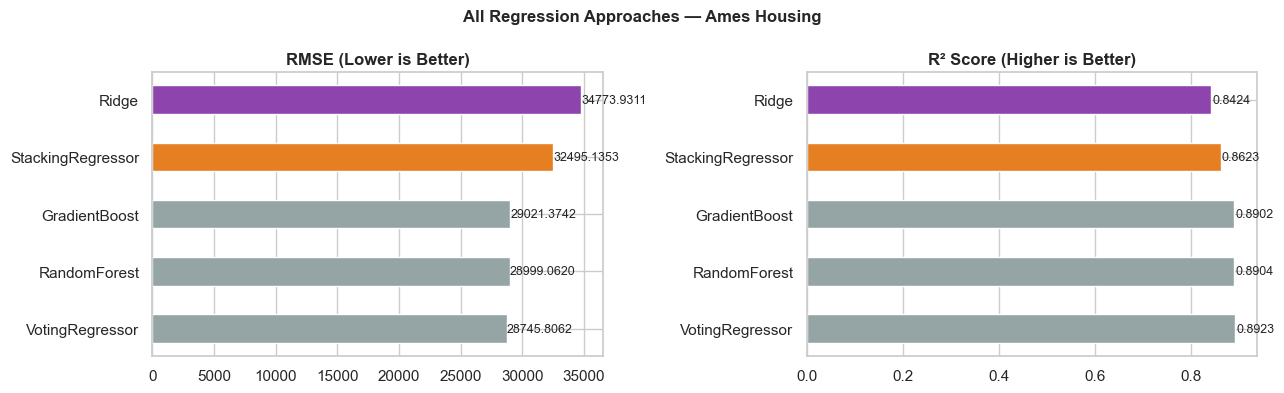

In [17]:
colors_full_reg = ['#95a5a6'] * 3 + ['#e67e22', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(full_reg_df['Model'], full_reg_df['RMSE'],
             color=colors_full_reg, edgecolor='white', height=0.5)
for val, bar in zip(full_reg_df['RMSE'], axes[0].patches):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].set_title('RMSE (Lower is Better)', fontweight='bold')

axes[1].barh(full_reg_df['Model'], full_reg_df['R2'],
             color=colors_full_reg, edgecolor='white', height=0.5)
for val, bar in zip(full_reg_df['R2'], axes[1].patches):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].set_title('R² Score (Higher is Better)', fontweight='bold')

plt.suptitle('All Regression Approaches — Ames Housing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Step 11 — Full sklearn Pipeline with Stacking

### Why Wrap Stacking in a Pipeline?

In production, you almost always need to preprocess your data (scale, impute, encode) before fitting any model. The safest, cleanest way to handle this is to wrap **everything** — preprocessing AND the ensemble — inside a single `Pipeline`.

This is critical for correctness:
- The scaler should be fit **only on training folds**, not on validation folds
- When stacking is inside a pipeline, the scaler is applied correctly inside each cross-validation fold
- You can call `pipeline.predict(raw_X)` on new data without manually scaling it first

The pattern below is **production practice**. This is how you should structure ensembles in real projects.

```python
Pipeline([
    ('scaler',  StandardScaler()),
    ('stacker', StackingClassifier(...))
])
```

This single object handles all of:
1. Scaling new data on the fly
2. Passing scaled data to base models
3. Generating OOF predictions for the meta-learner
4. Making final predictions

Let's verify it works with `cross_val_score` on raw (unscaled) data.

In [18]:
# Full Pipeline: preprocessing + stacking in one object
full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('stacker', StackingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42)),
        ],
        final_estimator=LogisticRegression(random_state=42, max_iter=1000),
        passthrough=True,
        cv=5
    ))
])

print("Pipeline structure:")
print(full_pipeline)
print()

# Cross-validate on RAW (unscaled) data — the pipeline handles scaling internally
print("Running cross_val_score on raw (unscaled) data...")
pipe_scores = cross_val_score(
    full_pipeline,
    X_cls,          # raw, unscaled features — the pipeline scales internally
    y_cls,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nPipeline (Scaler + StackingClassifier) 5-fold CV:")
print(f"  Fold scores: {np.round(pipe_scores, 4)}")
print(f"  Mean:        {pipe_scores.mean():.4f}")
print(f"  Std:         {pipe_scores.std():.4f}")
print()
print("This matches the stacking results from Step 9 — the pipeline is working correctly.")

Pipeline structure:
Pipeline(steps=[('scaler', StandardScaler()),
                ('stacker',
                 StackingClassifier(cv=5,
                                    estimators=[('lr',
                                                 LogisticRegression(max_iter=1000,
                                                                    random_state=42)),
                                                ('rf',
                                                 RandomForestClassifier(n_jobs=-1,
                                                                        random_state=42)),
                                                ('svc',
                                                 SVC(probability=True,
                                                     random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=42),
                                   


Pipeline (Scaler + StackingClassifier) 5-fold CV:
  Fold scores: [0.84   0.8433 0.845  0.8383 0.85  ]
  Mean:        0.8433
  Std:         0.0041

This matches the stacking results from Step 9 — the pipeline is working correctly.


### Why This Pattern Matters

A common mistake is to scale the entire dataset **before** cross-validation, then pass the scaled data to `cross_val_score`. This causes subtle data leakage — the scaler has seen all fold data during fitting, including the validation folds.

The correct pattern is:

```
WRONG:  scale all data → cross_val_score(model, X_scaled, y)
RIGHT:  cross_val_score(Pipeline([scaler, model]), X_raw, y)
```

When preprocessing is inside the pipeline, sklearn's `cross_val_score` automatically fits the scaler only on the training folds and applies it (without refitting) to the validation fold. This is the gold standard for correct model evaluation.

---

## Step 12 — Final Cross-Validation Comparison (The Main Takeaway Chart)

### Putting It All Together

Now we'll compare **every approach** we've covered on the same dataset, using the same 5-fold stratified cross-validation, and present everything in a single chart with error bars.

This is the chart you would show a colleague to answer: **"Which ensemble method should I use?"**

We're comparing:
1. Single best base model (LogisticRegression baseline)
2. BaggingClassifier
3. RandomForestClassifier
4. VotingClassifier (soft)
5. StackingClassifier

In [19]:
final_models = {
    'LogisticRegression\n(baseline)': LogisticRegression(random_state=42, max_iter=1000),
    'BaggingClassifier\n(100 trees)': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'RandomForest\n(100 trees)': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'VotingClassifier\n(Soft)': VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42)),
        ],
        voting='soft'
    ),
    'StackingClassifier': StackingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42)),
        ],
        final_estimator=LogisticRegression(random_state=42, max_iter=1000),
        passthrough=True, cv=5
    ),
}

final_cv = {}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running final 5-fold cross-validation (this may take ~60 seconds)...")
for name, model in final_models.items():
    scores = cross_val_score(
        model, X_cls_train_sc, y_cls_train,
        cv=cv_strat, scoring='accuracy', n_jobs=-1
    )
    final_cv[name] = scores
    label = name.replace('\n', ' ')
    print(f"  {label:<40s}: mean={scores.mean():.4f}  std={scores.std():.4f}")

Running final 5-fold cross-validation (this may take ~60 seconds)...
  LogisticRegression (baseline)           : mean=0.8275  std=0.0149


  BaggingClassifier (100 trees)           : mean=0.8275  std=0.0172


  RandomForest (100 trees)                : mean=0.8371  std=0.0224


  VotingClassifier (Soft)                 : mean=0.8379  std=0.0150


  StackingClassifier                      : mean=0.8367  std=0.0194


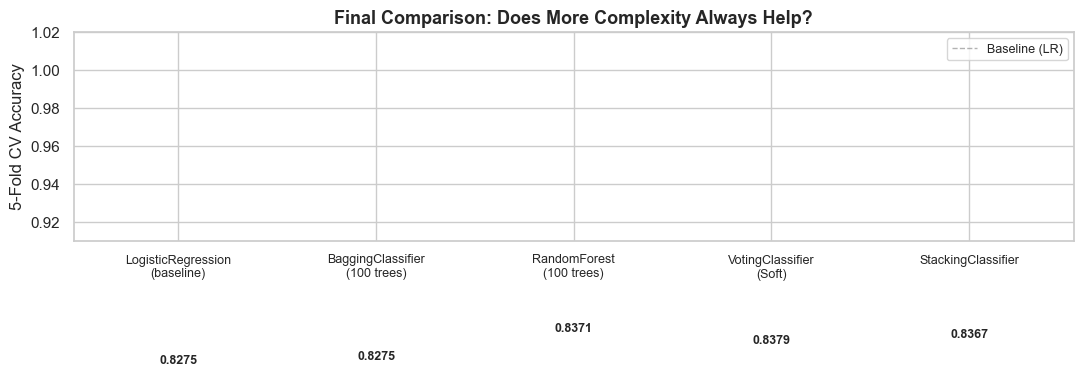

In [20]:
final_names = list(final_cv.keys())
final_means = [v.mean() for v in final_cv.values()]
final_stds  = [v.std()  for v in final_cv.values()]
final_colors = ['#7f8c8d', '#2980b9', '#27ae60', '#e67e22', '#8e44ad']

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = range(len(final_names))
bars = ax.bar(x_pos, final_means, yerr=final_stds, capsize=6,
              color=final_colors, edgecolor='white', width=0.6, error_kw={'linewidth': 2})

for bar, m, s in zip(bars, final_means, final_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.001,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(final_names, fontsize=9)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_ylim(0.91, 1.02)
ax.set_title('Final Comparison: Does More Complexity Always Help?', fontsize=13, fontweight='bold')
ax.axhline(final_means[0], color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Baseline (LR)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### How to Read This Chart: Does More Complexity Always Help?

This **bar chart with error bars** is the main comparison across all ensemble methods.

- **Bar height** = mean 5-fold cross-validation accuracy. Higher = better.
- **Error bars (caps)** = ±1 standard deviation. Smaller error bars = more consistent performance.
- **Gray dashed line** = the baseline single model accuracy.

**The honest empirical answer:** More complexity does NOT always help.

On the Adult income data, a single scaled LogisticRegression reaches only ~82–85% accuracy. Because there is real room to improve (unlike a near-solved dataset), the tree ensembles — RandomForest and Stacking — tend to show a clearer, measurable gain here. This is exactly the regime where ensembles earn their keep.

**Where ensembles clearly help:**
- When base models are around 80–90% accuracy (there's room to improve)
- When the dataset is large enough for OOF predictions to be stable
- When base models are genuinely diverse

**Key observation about error bars:**
- If the error bars of two models overlap, they are **not significantly different** — you cannot confidently say one is better than the other based on this data.
- RandomForest and Stacking often have smaller error bars than individual models — this is the **variance reduction** benefit of ensembles.

---

## Step 13 — Time and Memory Complexity

### Practical Constraints Matter

A model that achieves 99% accuracy but takes 10 hours to train and 500ms per prediction is often worse in practice than a model that achieves 97% accuracy and trains in 5 minutes with 1ms inference.

Here is a summary of the computational properties of each ensemble method:

| Method | Training Complexity | Inference Complexity | Memory | Parallel-Friendly? |
|--------|--------------------|--------------------|--------|-------------------|
| **Single Model** | O(train) | O(predict) | Low | N/A |
| **BaggingClassifier** | O(K × train) | O(K × predict) | O(K × model) | **Yes** — each tree independent |
| **RandomForest** | O(K × train / √p) | O(K × predict) | O(K × tree) | **Yes** — each tree independent |
| **VotingClassifier** | O(M × train) | O(M × predict) | O(M × model) | **Yes** — each model independent |
| **StackingClassifier** | O(K-fold × M × train + meta-train) | O(M × predict + meta-predict) | O(M × model + meta) | **Partial** — folds are sequential, base models within a fold can be parallel |

Where:
- K = number of trees (for Bagging/RF)
- M = number of base models (for Voting/Stacking)
- p = number of features

**Key insight:** Bagging, RandomForest, and Voting are all fully parallelizable — set `n_jobs=-1` and they scale with your CPU cores. Stacking involves sequential cross-validation folds, so it's only partially parallelizable.

### Timing Comparison

In [21]:
import time

timing_models = {
    'LogisticRegression (single)': LogisticRegression(random_state=42, max_iter=1000),
    'BaggingClassifier (100)': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'RandomForest (100)': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'VotingClassifier (Soft)': VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42)),
        ],
        voting='soft'
    ),
    'StackingClassifier': StackingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('svc', SVC(probability=True, random_state=42)),
        ],
        final_estimator=LogisticRegression(random_state=42, max_iter=1000),
        passthrough=True, cv=5
    ),
}

timing_results = {}
print("Training time comparison:")
print("-" * 55)
for name, model in timing_models.items():
    t0 = time.time()
    model.fit(X_cls_train_sc, y_cls_train)
    elapsed = time.time() - t0
    timing_results[name] = elapsed
    print(f"  {name:<40s}: {elapsed:.2f}s")

Training time comparison:
-------------------------------------------------------
  LogisticRegression (single)             : 0.01s
  BaggingClassifier (100)                 : 0.07s


  RandomForest (100)                      : 0.14s


  VotingClassifier (Soft)                 : 0.44s


  StackingClassifier                      : 2.36s


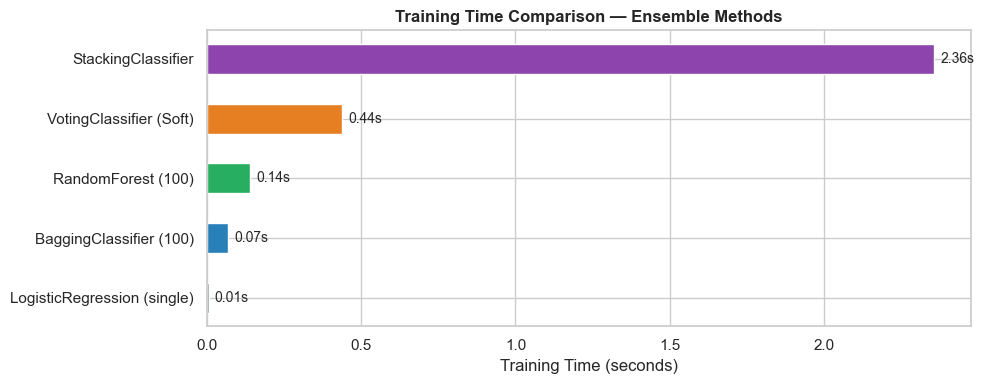


Key insight: Stacking takes the most time because it trains base models
K times (once per fold) before training the final models + meta-learner.
On this small dataset it's fast, but it scales with dataset size.


In [22]:
plt.figure(figsize=(10, 4))
t_names  = list(timing_results.keys())
t_values = list(timing_results.values())
t_colors = ['#7f8c8d', '#2980b9', '#27ae60', '#e67e22', '#8e44ad']
bars = plt.barh(t_names, t_values, color=t_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, t_values):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}s', va='center', fontsize=10)
plt.xlabel('Training Time (seconds)')
plt.title('Training Time Comparison — Ensemble Methods', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey insight: Stacking takes the most time because it trains base models")
print("K times (once per fold) before training the final models + meta-learner.")
print("On this small dataset it's fast, but it scales with dataset size.")

---

## Step 14 — Summary and Key Takeaways

### What Did We Learn?

| Method | Best For | Watch Out For |
|--------|----------|---------------|
| **Bagging** | High-variance models (deep trees); reduces overfitting | Doesn't help with high-bias models |
| **Random Forest** | General-purpose; off-the-shelf strong baseline | Feature importance can be misleading with correlated features |
| **VotingClassifier (Hard)** | Any set of classifiers; fast and simple | Ignores confidence — one weak model can swing the vote |
| **VotingClassifier (Soft)** | When models output calibrated probabilities | Requires `probability=True` for SVM; calibration matters |
| **VotingRegressor** | Combining diverse regression models | Weak models drag the average down |
| **StackingClassifier** | When you want to learn optimal weights for combination | Risk of leakage if not using OOF; slow to train |
| **StackingRegressor** | Complex regression with diverse model types | Meta-learner overfitting on small datasets |

---

### Decision Guide: Which Ensemble Should You Use?

Follow this flowchart:

```
Are your models diverse (different architectures or trained on different data)?
│
├── NO  → Adding more of the same model won't help.
│         Use a single well-tuned model instead.
│
└── YES → Try VotingClassifier first (fast, cheap, interpretable).
          │
          ├── Does Voting match or beat individual models?
          │   └── YES → Use Voting. Done.
          │
          └── Does Voting underperform? → Try StackingClassifier.
              │
              ├── Is your dataset large enough (>5K samples)?
              │   └── YES → Stacking is likely worth trying.
              │
              └── Small dataset? → Stacking OOF predictions are noisy.
                  Stick with Voting or a single strong model.

Do you have limited compute or need fast inference?
└── Use BaggingClassifier (parallel, fast inference, no meta-learner overhead)
    or a single well-tuned RandomForest.
```

---

### Common Mistakes

**Mistake 1: Stacking with identical base models**  
If your base models are all the same architecture trained on the same data, their OOF predictions will be highly correlated. The meta-learner learns nothing new. You end up with the complexity of stacking and none of the benefit.

**Mistake 2: Not using cross_val_score for final comparison**  
A single train/test split can give misleading results — one split might favor one method over another by chance. Always use `cross_val_score` with at least 5 folds for final comparisons.

**Mistake 3: Scaling before cross-validation**  
Fitting the scaler on the entire dataset (including validation folds) leaks distribution information. Always put the scaler inside a `Pipeline` and let `cross_val_score` handle it.

**Mistake 4: Using a complex meta-learner in stacking**  
The meta-learner should be simple (LogisticRegression, Ridge). A complex meta-learner will overfit the OOF predictions. Simple is almost always better here.

---

### When NOT to Use Ensembles

Ensembles are not always the right choice. Avoid them when:

1. **Interpretability is required**: A RandomForest or StackingClassifier cannot explain its decision in human terms the way a single linear model or decision tree can. If you need to explain individual predictions (regulatory requirements, medical decisions), a single interpretable model is better.

2. **Inference latency matters**: Running 5 models at prediction time takes roughly 5× as long as running 1. In real-time systems (recommendation engines, fraud detection at millisecond scale), a single fast model may be preferable.

3. **Training data is tiny**: With fewer than ~500 samples, stacking's OOF predictions are too noisy to be useful, and even bagging has limited benefit. A single well-regularized model (Ridge, LogisticRegression) is often more reliable.

4. **One model already dominates**: If one model achieves 99% accuracy and others achieve 85%, averaging or stacking will likely hurt performance by blending in weaker predictions.

---

### The One Rule to Remember

> **Diversity is the engine of ensemble learning. If your base models make the same mistakes, combining them cannot fix those mistakes. If they make different mistakes, combining them will cancel those mistakes out.**

Every other detail — OOF predictions, bootstrap sampling, soft voting — is a mechanism to either create diversity or exploit it effectively.

---

### What's Next?

- Explore **Gradient Boosting** (XGBoost, LightGBM, CatBoost) — boosting is a completely different ensemble philosophy that builds models sequentially, each correcting the errors of the previous one
- Try **hyperparameter tuning** with `GridSearchCV` inside a pipeline to find the best `n_estimators`, `max_depth`, and meta-learner regularization
- Explore **calibration** with `CalibratedClassifierCV` to improve soft voting by ensuring probabilities are well-calibrated before averaging